In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

df = pd.read_csv("vinhos_dataset.csv")

In [59]:
df.duplicated().sum()

np.int64(1177)

In [60]:
df[df.duplicated()]

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.400000,5,red
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.500000,5,red
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.500000,5,red
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.500000,5,red
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.900000,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6427,6.4,0.230,0.35,10.30,0.042,54.0,140.0,0.99670,3.23,0.47,9.200000,5,white
6449,7.0,0.360,0.35,2.50,0.048,67.0,161.0,0.99146,3.05,0.56,11.100000,6,white
6450,6.4,0.330,0.44,8.90,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,5,white
6455,7.1,0.230,0.39,13.70,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6,white


In [61]:
# Carregar o dataset original
df = pd.read_csv("vinhos_dataset.csv")

# Remover duplicados e resetar o índice
df_cleaned = df.drop_duplicates().reset_index(drop=True)

# Definir APENAS as variáveis numéricas que devem ser padronizadas
features = [
    'fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
    'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
    'pH', 'sulphates', 'alcohol'
]

In [62]:
# Carrega df sem duplicados
df_cleaned = pd.read_csv("vinhos_dataset_cleaned.csv")

# Checar se as linhas foram removidas
df_cleaned.shape


(5320, 13)

In [63]:
# Carregar o arquivo original (apos remocao de duplicados)
df = pd.read_csv('vinhos_dataset_cleaned.csv')

# Criar os componentes principais (PCA)
pca_acidity = PCA(n_components=1)
df['combined_acidity'] = pca_acidity.fit_transform(df[['fixed_acidity', 'volatile_acidity']])

pca_so2 = PCA(n_components=1)
df['combined_sulfur_dioxide'] = pca_so2.fit_transform(df[['free_sulfur_dioxide', 'total_sulfur_dioxide']])

# Criar uma nova versão sem as 4 colunas originais
df_reduced = df.drop(columns=[
    'fixed_acidity', 
    'volatile_acidity', 
    'free_sulfur_dioxide', 
    'total_sulfur_dioxide'
])

# 4. Salvar em um NOVO arquivo na mesma pasta (sem sobrescrever o original)
nome_novo_arquivo = 'vinhos_dataset_reduced.csv'
df_reduced.to_csv(nome_novo_arquivo, index=False)

In [64]:
# Carregar o arquivo reduzido (apos remocao de duplicados e combinadas as 4 colunas - reducao de dimensionalidade)
df_reduced = pd.read_csv('vinhos_dataset_reduced.csv')

# verificando a dl sem duplicados
df_reduced[df_reduced.duplicated()]


,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide


In [65]:
df_reduced.head()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide
0,-2.164515,-0.699699,0.523880,1.100996,1.779304,0.177941,-0.969152,5,red,1.594818,-1.753919
1,-2.164515,-0.544135,1.120736,0.763753,-0.153797,0.979389,-0.631833,5,red,2.565734,-0.786828
2,-1.892672,-0.610806,0.957957,0.831202,0.220351,0.779027,-0.631833,5,red,2.061356,-1.345931
3,1.641293,-0.699699,0.496751,1.168444,-0.403229,0.311515,-0.631833,6,red,1.865803,-1.191760
4,-2.164515,-0.721923,0.496751,1.100996,1.779304,0.177941,-0.969152,5,red,1.426692,-1.599748


In [66]:
df_reduced.tail()


,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide
5315,-0.193650,-0.766370,-0.479922,-1.145039,0.282710,-0.222784,0.548783,6,white,-1.107772,-0.515149
5316,0.282076,0.655929,-0.262884,0.122993,-0.465588,-0.489933,-0.800493,5,white,-0.431077,1.742179
5317,-0.873259,-0.855263,-0.425662,-0.672899,-1.463317,-0.489933,-0.969152,6,white,-0.820917,-0.040181
5318,-0.125689,-0.877487,-0.941128,-1.971283,0.719216,-1.024232,1.898059,7,white,-1.146630,-0.449813
5319,0.417998,-0.944157,-0.995388,-1.728468,0.220351,-1.424957,1.054761,6,white,-1.214947,-0.519849


In [67]:
df_reduced.shape

(5320, 11)

In [68]:
df_reduced.columns

Index(['citric_acid', 'residual_sugar', 'chlorides', 'density', 'pH',
       'sulphates', 'alcohol', 'quality', 'color', 'combined_acidity',
       'combined_sulfur_dioxide'],
      dtype='str')

In [69]:
df_reduced.dtypes

citric_acid                float64
residual_sugar             float64
chlorides                  float64
density                    float64
pH                         float64
sulphates                  float64
alcohol                    float64
quality                      int64
color                          str
combined_acidity           float64
combined_sulfur_dioxide    float64
dtype: object

In [70]:
df_reduced.info()

<class 'pandas.DataFrame'>
RangeIndex: 5320 entries, 0 to 5319
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   citric_acid              5320 non-null   float64
 1   residual_sugar           5320 non-null   float64
 2   chlorides                5320 non-null   float64
 3   density                  5320 non-null   float64
 4   pH                       5320 non-null   float64
 5   sulphates                5320 non-null   float64
 6   alcohol                  5320 non-null   float64
 7   quality                  5320 non-null   int64  
 8   color                    5320 non-null   str    
 9   combined_acidity         5320 non-null   float64
 10  combined_sulfur_dioxide  5320 non-null   float64
dtypes: float64(9), int64(1), str(1)
memory usage: 457.3 KB


In [71]:
df_reduced.describe()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,combined_acidity,combined_sulfur_dioxide
count,5.320000e+03,5.320000e+03,5.320000e+03,5.320000e+03,5.320000e+03,5.320000e+03,5.320000e+03,5320.000000,5320.000000,5320.000000
mean,4.273941e-17,2.136971e-17,1.495879e-16,1.852754e-14,6.197215e-16,-2.136971e-17,6.517760e-16,5.795677,0.000000,0.000000
std,1.000094e+00,1.000094e+00,1.000094e+00,1.000094e+00,1.000094e+00,1.000094e+00,1.000094e+00,0.879772,1.102262,1.311797
min,-2.164515e+00,-9.886039e-01,-1.293816e+00,-2.504125e+00,-3.146985e+00,-2.092831e+00,-2.149768e+00,3.000000,-2.347641,-2.420424
25%,-5.334545e-01,-7.219228e-01,-5.070517e-01,-7.875618e-01,-7.150198e-01,-6.902954e-01,-8.848223e-01,5.000000,-0.759965,-0.928893
50%,-5.772841e-02,-5.219120e-01,-2.628836e-01,3.868208e-02,-9.143899e-02,-1.559963e-01,-1.258547e-01,6.000000,-0.304983,-0.040181
75%,5.539194e-01,5.448122e-01,2.525824e-01,7.536359e-01,6.568580e-01,4.450903e-01,7.174425e-01,6.000000,0.517236,0.871856
max,9.116989e+00,1.350107e+01,1.503832e+01,1.498864e+01,4.897208e+00,9.795325e+00,3.668983e+00,9.000000,5.925913,14.344658


In [72]:
df_reduced.describe(include="all")

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide
count,5.320000e+03,5.320000e+03,5.320000e+03,5.320000e+03,5.320000e+03,5.320000e+03,5.320000e+03,5320.000000,5320,5320.000000,5320.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,white,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3961,NaN,NaN
mean,4.273941e-17,2.136971e-17,1.495879e-16,1.852754e-14,6.197215e-16,-2.136971e-17,6.517760e-16,5.795677,NaN,0.000000,0.000000
std,1.000094e+00,1.000094e+00,1.000094e+00,1.000094e+00,1.000094e+00,1.000094e+00,1.000094e+00,0.879772,NaN,1.102262,1.311797
min,-2.164515e+00,-9.886039e-01,-1.293816e+00,-2.504125e+00,-3.146985e+00,-2.092831e+00,-2.149768e+00,3.000000,NaN,-2.347641,-2.420424
25%,-5.334545e-01,-7.219228e-01,-5.070517e-01,-7.875618e-01,-7.150198e-01,-6.902954e-01,-8.848223e-01,5.000000,NaN,-0.759965,-0.928893
50%,-5.772841e-02,-5.219120e-01,-2.628836e-01,3.868208e-02,-9.143899e-02,-1.559963e-01,-1.258547e-01,6.000000,NaN,-0.304983,-0.040181
75%,5.539194e-01,5.448122e-01,2.525824e-01,7.536359e-01,6.568580e-01,4.450903e-01,7.174425e-01,6.000000,NaN,0.517236,0.871856


In [73]:
df_reduced.isnull().sum()

citric_acid                0
residual_sugar             0
chlorides                  0
density                    0
pH                         0
sulphates                  0
alcohol                    0
quality                    0
color                      0
combined_acidity           0
combined_sulfur_dioxide    0
dtype: int64

In [74]:
df_reduced.isnull().mean() * 100

citric_acid                0.0
residual_sugar             0.0
chlorides                  0.0
density                    0.0
pH                         0.0
sulphates                  0.0
alcohol                    0.0
quality                    0.0
color                      0.0
combined_acidity           0.0
combined_sulfur_dioxide    0.0
dtype: float64

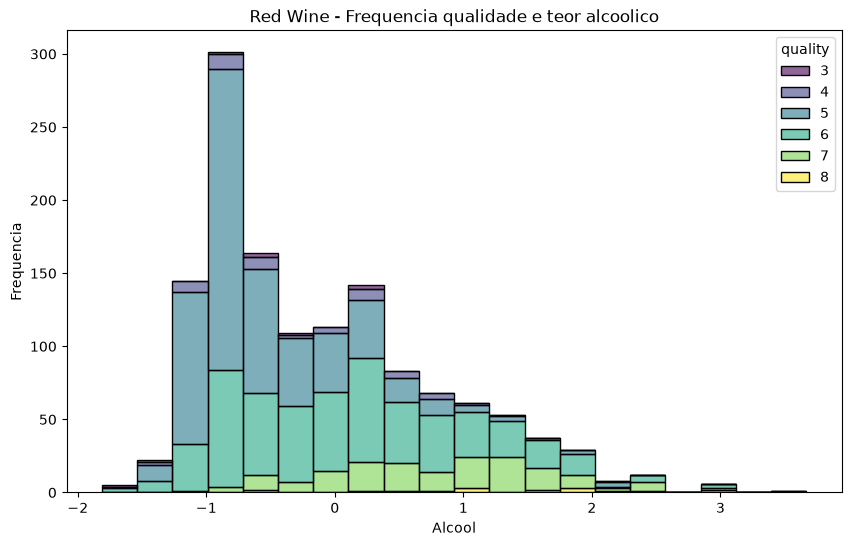

In [75]:

# Grafico de frequencia dequalidade e teor alcoolico red wine
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_reduced[df_reduced['color'] == 'red'],
    x='alcohol',
    hue='quality',
     palette="viridis",
    multiple='stack',
    bins=20,
    alpha=0.6
)

plt.title('Red Wine - Frequencia qualidade e teor alcoolico')
plt.xlabel('Alcool')
plt.ylabel('Frequencia')
plt.show()

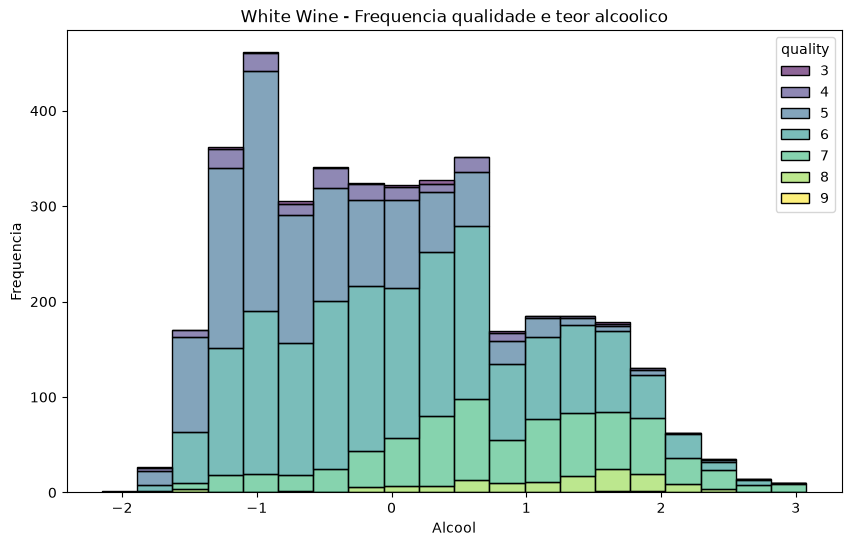

In [76]:
# Grafico de qualidade por teor alcoolico white wine
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_reduced[df_reduced['color'] == 'white'],
    x='alcohol',
    hue='quality',
    palette="viridis",
    multiple='stack',
    bins=20,
    alpha=0.6
)

plt.title('White Wine - Frequencia qualidade e teor alcoolico')
plt.xlabel('Alcool')
plt.ylabel('Frequencia')
plt.show()

In [77]:
df_reduced["color"].value_counts()

color
white    3961
red      1359
Name: count, dtype: int64

In [78]:
df_reduced["color"].value_counts(normalize=True) * 100

color
white    74.454887
red      25.545113
Name: proportion, dtype: float64

In [79]:
df_reduced["quality"].value_counts()

quality
6    2323
5    1752
7     856
4     206
8     148
3      30
9       5
Name: count, dtype: int64

In [80]:
df_reduced["quality"].value_counts(normalize=True) * 100

quality
6    43.665414
5    32.932331
7    16.090226
4     3.872180
8     2.781955
3     0.563910
9     0.093985
Name: proportion, dtype: float64

In [81]:
from sklearn.preprocessing import StandardScaler

In [82]:
# Quais colunas para "scale" (Novas colunas criadas de acidity e sulfor ja estao em escala)
features = [
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'density',
    'pH',
    'sulphates',
    'alcohol' ,
]

# Criado o scaler
scaler = StandardScaler()

# Scale calcula a media e o desvio padrao de cada "feature" e transforma usando a formula z = X - X_mean / X_std - agora todos os valores estao em escalas parecidas e nao pH entre 1 e 14 e sultatios entre 0 e 1 por examplo
df_reduced[features] = scaler.fit_transform(df_reduced[features])

# Mostra as colunas com dados estatisticos basicos
df_reduced.describe(include="all")

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide
count,5.320000e+03,5320.000000,5.320000e+03,5.320000e+03,5.320000e+03,5320.000000,5.320000e+03,5320.000000,5320,5320.000000,5320.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,white,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3961,NaN,NaN
mean,2.404092e-17,0.000000,-4.273941e-17,2.136971e-17,-4.273941e-17,0.000000,1.068485e-17,5.795677,NaN,0.000000,0.000000
std,1.000094e+00,1.000094,1.000094e+00,1.000094e+00,1.000094e+00,1.000094,1.000094e+00,0.879772,NaN,1.102262,1.311797
min,-2.164515e+00,-0.988604,-1.293816e+00,-2.504125e+00,-3.146985e+00,-2.092831,-2.149768e+00,3.000000,NaN,-2.347641,-2.420424
25%,-5.334545e-01,-0.721923,-5.070517e-01,-7.875618e-01,-7.150198e-01,-0.690295,-8.848223e-01,5.000000,NaN,-0.759965,-0.928893
50%,-5.772841e-02,-0.521912,-2.628836e-01,3.868208e-02,-9.143899e-02,-0.155996,-1.258547e-01,6.000000,NaN,-0.304983,-0.040181
75%,5.539194e-01,0.544812,2.525824e-01,7.536359e-01,6.568580e-01,0.445090,7.174425e-01,6.000000,NaN,0.517236,0.871856
